In [249]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import uncertainties as un
import uncertainties.unumpy as unp
from uncertainties.unumpy import nominal_values as noms
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from vtools import plot as vplt

try:
    from blazy import iphreeqc
    have_blazy = True
except ImportError:
    have_blazy = False
    raise ImportError("the blazy package is not present - this is likely because it is still in development, and you do not have access to it. Falling back to loading previously computed data.")

In [250]:
compositions = pd.read_pickle('data/vaterite_processed.pkl')
compositions.solution_start.head()

Quantity,B,B/C,C,Ca,Mg,Mg/Ca,Na,Na/Ca,Sr,Sr/Ca,pH_NBS
Instrument,Agilent,calc,dissolution,Agilent,Agilent,calc,Agilent,calc,Agilent,calc,electrode
Unit,mmol,mol/mol,mmol,mmol,mmol,mol/mol,mmol,mol/mol,mmol,mol/mol,Unnamed: 29_level_3
15,0.0101+/-0.0005,0.00202+/-0.00010,5,12.8+/-0.6,-0.00143+/-0.00007,-0.000111+/-0.000008,0.248+/-0.012,0.0193+/-0.0014,0.00101+/-0.00005,(7.9+/-0.6)e-05,8.213
16,0.0452+/-0.0023,0.0090+/-0.0005,5,12.2+/-0.6,1.03+/-0.05,0.084+/-0.006,0.225+/-0.011,0.0184+/-0.0013,0.00096+/-0.00005,(7.9+/-0.6)e-05,8.209
17,0.0185+/-0.0009,0.00370+/-0.00018,5,10.7+/-0.5,2.07+/-0.10,0.193+/-0.014,0.233+/-0.012,0.0218+/-0.0015,0.00087+/-0.00004,(8.1+/-0.6)e-05,8.193
18,0.0302+/-0.0015,0.00605+/-0.00030,5,10.7+/-0.5,4.93+/-0.25,0.460+/-0.033,0.223+/-0.011,0.0209+/-0.0015,0.00089+/-0.00004,(8.3+/-0.6)e-05,8.200
19,0.0122+/-0.0006,0.00244+/-0.00012,5,11.6+/-0.6,9.4+/-0.5,0.81+/-0.06,0.214+/-0.011,0.0185+/-0.0013,0.00112+/-0.00006,(9.6+/-0.7)e-05,8.198


In [251]:
profiles = pd.read_csv('data/pH_profiles_clean.csv', header=[0,1], index_col=0)
profiles.head()

,15,16,17,18,19,20,21,22,23,24,...,38,39,40,41,42,43,44,45,46,47
t / h,pH,pH,pH,pH,pH,pH,pH,pH,pH,pH,...,pH,pH,pH,pH,pH,pH,pH,pH,pH,pH
0.000000,8.188,8.211,8.194,8.200,8.197,8.206,8.207,8.201,8.214,8.214,...,8.221,8.206,8.215,8.215,8.205,8.196,8.196,8.201,8.194,8.204
0.001389,8.172,8.208,8.193,8.197,8.193,8.204,8.206,8.190,8.211,8.213,...,8.215,8.205,8.212,8.214,8.201,8.192,8.194,8.199,8.185,8.203
0.002778,8.158,8.198,8.192,8.183,8.187,8.199,8.204,8.170,8.195,8.207,...,8.187,8.188,8.184,8.210,8.184,8.139,8.192,8.188,8.143,8.194
0.004167,8.147,8.175,8.186,8.171,8.186,8.197,8.203,8.158,8.178,8.187,...,8.160,8.149,8.158,8.172,8.144,8.116,8.184,8.146,8.123,8.161
0.005556,8.137,8.163,8.175,8.165,8.184,8.195,8.201,8.145,8.163,8.168,...,8.151,8.135,8.142,8.152,8.130,8.108,8.124,8.123,8.105,8.135


## Calculate solution evolution

In [252]:
if have_blazy:
    solcalc = iphreeqc('data/pitzer_vat.dat')
    
    for exp in profiles.columns.levels[0]:
        pH = profiles.loc[:, str(exp)]
        c = compositions.loc[int(exp), 'solution_start']

        # create initial solution
        start = {
            'temp': 25.0,
            'pH': pH.loc[0].item(),
            'Na': noms(c['Na']).item(),
            'Cl': noms(c['Na'] + c['Ca'] * 1e-3 / 2 + c['Mg'] * 1e-3 / 2).item(),  # NaCl + CaCl2 + MgCl2
            'Ca': noms(c['Ca']).item() * 1e-3,
            'Mg': noms(c['Mg']).item() * 1e-3,
            'Sr': noms(c['Sr']).item() * 1e-3,
            'B': noms(c['B']).item() * 1e-3,
            'C': 0.005,  # where does this come from?
            'unit': 'mol/kgw',
        }
        
        # calculate initial state of solution
        initial = solcalc.run(start, targets=['Ca'])
        
        for phase in ['Vaterite', 'Aragonite', 'Calcite']:
            iS = initial[('log10(saturation)', phase)]

            # calculate relationship between pH and vaterite saturation
            eqp = [[(phase, log10si.item())] for log10si in np.linspace(iS, 0, 10)]
            eq = solcalc.run(start, targets=['Ca', 'C'], equilibrium_phases=eqp)
            eq_react = eq.loc[eq.general.state == 'react']
            
            with open(f'data/phreeqc_runfiles/{exp}_{phase}_equil.phreeqc', 'w') as f:
                f.write(solcalc._input_string)

            # create interpolators to calculate saturation and Ca from pH
            est_log10S = interp1d(eq_react.general.pH, eq_react[('log10(saturation)', phase)], bounds_error=False)
            profiles[(str(exp), 'log10S' + phase[0])] = est_log10S(profiles[(str(exp), 'pH')])
            
        est_Ca = interp1d(eq_react.general.pH, eq_react[('molality (mol/kgw)', 'Ca+2')], bounds_error=False)
        profiles[(str(exp), 'Ca')] = est_Ca(profiles[(str(exp), 'pH')])
        profiles.loc[0, (str(exp), 'Ca')] = start['Ca']
        
        # use these interpolators to calculate saturation and Ca from pH
        
    profiles.sort_index(1, inplace=True)

    profiles.to_pickle('data/pH_profiles_PHREEQC.pkl')

else:
    profiles = pd.read_pickle('data/pH_profiles_PHREEQC.pkl')

Using pitzer_vat.dat
   Pitzer.DAT for calculating pressure dependence of reactions
   and temperature dependence to 200 °C. With
   molal volumina of aqueous species and of minerals, and
   critical temperatures and pressures of gases used in Peng-Robinson's EOS.
   Coefficients for vaterite added by Lara Jurkovic on 26/05/2022
   Details are given at the end of this file.


/tmp/ipykernel_7311/2307018194.py:46: FutureWarning: In a future version of pandas all arguments of DataFrame.sort_index will be keyword-only.
  profiles.sort_index(1, inplace=True)


## Kinetic Calculations

In [253]:
Ai = 0.64  # m2 g-1 

rate_window = 21

profiles.loc[:, ('time', 'dt / h')] = profiles.reset_index()['index'].diff(rate_window).shift(-rate_window).values
profiles.loc[:, ('time', 'dt / s')] = profiles.loc[:, ('time', 'dt / h')] * 60**2

for exp in profiles.columns.levels[0]:
    if exp == 'time':
        continue
    
    profiles.loc[:, (exp, 'SV')] = 10**profiles.loc[:, (exp, 'log10SV')]
    profiles.loc[:, (exp, 'SC')] = 10**profiles.loc[:, (exp, 'log10SC')]
    
    profiles.loc[:, (exp, 'log10(SV_1)')] = np.log10(profiles.loc[:, (exp, 'SV')] - 1)
    profiles.loc[:, (exp, 'log10(SC_1)')] = np.log10(profiles.loc[:, (exp, 'SC')] - 1)
    
    profiles.loc[:, (exp, 'ln(SV)')] = np.log(profiles.loc[:, (exp, 'SV')])
    profiles.loc[:, (exp, 'ln(SC)')] = np.log(profiles.loc[:, (exp, 'SC')])
    
    profiles.loc[:, (exp, 'dCa')] = profiles.loc[:, (exp, 'Ca')].diff(rate_window).shift(-rate_window)  # M
    # profiles.loc[:, (exp, 'dt / h')] = profiles.loc[:, (exp, 't / h')].diff(rate_window)  # hours
    # profiles.loc[:, (exp, 'dt / s')] = profiles.loc[:, (exp, 'dt / h')] * 60**2  # seconds
    
    profiles.loc[:, (exp, 'dCa_dt / s')] = profiles.loc[:, (exp, 'dCa')] / profiles.loc[:, ('time', 'dt / s')]
    
    profiles.loc[:, (exp, 'A')] = Ai * (1 + (profiles.loc[:, (exp, 'Ca')] - profiles.loc[:, (exp, 'Ca')].max()) * 100.09 / 0.1)**(2/3)
    
    profiles.loc[:, (exp, 'dCa_dt_A')] = profiles.loc[:, (exp, 'dCa_dt / s')] / profiles.loc[:, (exp, 'A')]
    profiles.loc[:, (exp, 'R')] = profiles.loc[:, (exp, 'dCa_dt_A')] * -1
    
    og_F_V = noms(compositions.loc[int(exp), ('overgrowth', 'F_V')])
    Ca_change_total = profiles.loc[0, (exp, 'Ca')] - profiles.loc[:, (exp, 'Ca')].min()
    Ca_change_V = Ca_change_total * og_F_V
    
    profiles.loc[:, (exp, 'precip_V')] = profiles.loc[:, (exp, 'Ca')] >= (profiles.loc[0, (exp, 'Ca')] - Ca_change_V.item())
    
    # vaterite growth
    
profiles.sort_index(1, inplace=True)

/tmp/ipykernel_7311/3310540272.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profiles.loc[:, (exp, 'dCa_dt_A')] = profiles.loc[:, (exp, 'dCa_dt / s')] / profiles.loc[:, (exp, 'A')]
/tmp/ipykernel_7311/3310540272.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profiles.loc[:, (exp, 'R')] = profiles.loc[:, (exp, 'dCa_dt_A')] * -1
/tmp/ipykernel_7311/3310540272.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Conside

In [254]:
exp = '46'
og_F_V = noms(compositions.loc[int(exp), ('overgrowth', 'F_V')])
Ca_change_total = profiles.loc[:, (exp, 'Ca')].max() - profiles.loc[:, (exp, 'Ca')].min()
Ca_change_V = Ca_change_total * og_F_V

### Calculations assuming Spiral Growth

In [255]:
from sklearn.metrics import r2_score

def R_spiral_growth(S, k, lnS_critical):
    return k * (S - 1) * (np.log(S) - lnS_critical)

In [280]:
kinetics = pd.DataFrame(index=compositions.index, columns=pd.MultiIndex.from_tuples([('kinetics', 'k', 'calc', 'mol/m2/s'),('kinetics', 'lnS_critical', 'calc', None), ('kinetics', 'R2', 'calc', None)]), dtype=object)
kinetics.sort_index(axis=1, inplace=True)

for exp in profiles.columns.levels[0]:
    if exp == 'time':
        continue
    ind = profiles.loc[:, (exp, 'precip_V')]
    x = profiles.loc[ind, (exp, 'SV')]
    y = profiles.loc[ind, (exp, 'R')]
    
    isnan = np.isnan(x) | np.isnan(y)
    
    if sum(~isnan) < 3:
        continue
    
    x = x[~isnan].values
    y = y[~isnan].values
    
    try:
        p, cov = curve_fit(R_spiral_growth, x, y, (1e-8, 0))
        up = un.correlated_values(p, cov)
        
        pred = R_spiral_growth(x, *p)
        
        r2 = r2_score(y, pred)
    except RuntimeError:
        pass
    
    kinetics.loc[int(exp), ('kinetics', 'k', 'calc', 'mol/m2/s')] = up[0]
    kinetics.loc[int(exp), ('kinetics', 'lnS_critical', 'calc')] = up[1]
    kinetics.loc[int(exp), ('kinetics', 'R2', 'calc')] = r2

In [281]:
# combine data
dat = compositions.join(kinetics).sort_index(axis=1)

no_high_mg = (dat.solution_start['Mg/Ca'] < 3).values  # exclude high Mg point that grew aragonite
vaterite_growth = dat.overgrowth.F_V.values >= 0  # only select data where vaterite grew

good_kinetic_fits = (dat.kinetics.R2 > 0.95).values



## Plotting

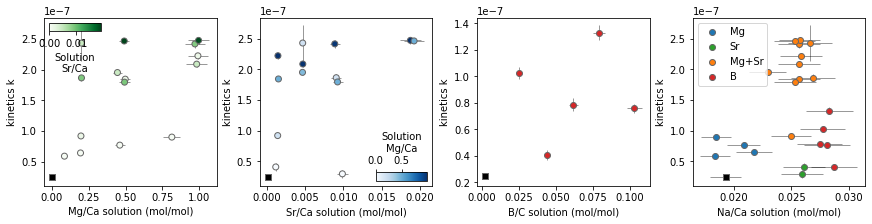

In [282]:
yvar = ('kinetics', 'k')
fig, axs = vplt.solution_vs_yvar(dat.loc[no_high_mg & vaterite_growth & good_kinetic_fits], yvar=yvar)


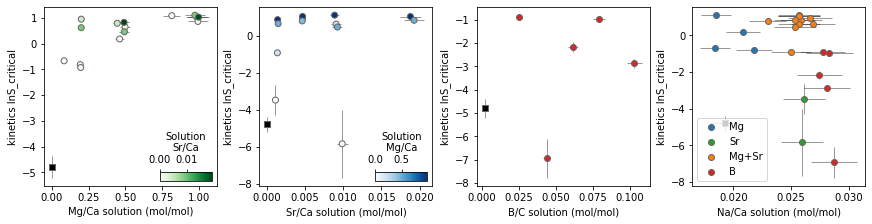

In [283]:
yvar = ('kinetics', 'lnS_critical')
fig, axs = vplt.solution_vs_yvar(dat.loc[no_high_mg & vaterite_growth & good_kinetic_fits], yvar=yvar)

In [284]:
# exps = profiles.columns.levels[0]
# exps = ['30']

exps = ['15', '16', '17', '18', '19']  # Mg experiments   '20' and '21' - aragonite experiment
# exps = ['15', '22', '24', '25', '26']  # Sr experiments = '23' didn't grow
# exps = ['15', '30', '31', '32', '33', '35', '37', '38', '39', '40', '41', '42']  # Mg & Sr experiments - '36' didn't grow
# exps = ['15', '43', '44', '45', '46', '47']  # B experiments

### Note: have a look at XRD for #39

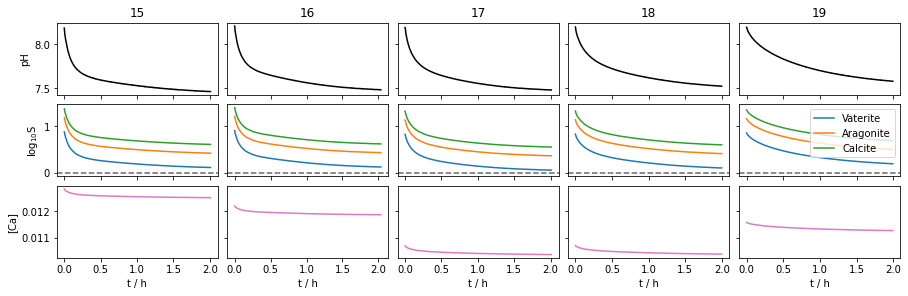

In [291]:
n = len(exps)
fig, axs = plt.subplots(3, n, sharey='row', sharex='col', figsize=[n * 2.5, 4], constrained_layout=True)
if axs.ndim == 1:
    axs = axs.reshape(-1, 1)

for exp, col in zip(exps, axs.T):
    ph, sat, ca = col
    sub = profiles.loc[:, exp]
    
    ph.set_title(exp)
    
    ph.plot('pH', data=sub, color='k')
    
    for phase in ['Vaterite', 'Aragonite', 'Calcite']:
        sat.plot('log10S' + phase[0], data=sub, label=phase)
    
    ca.plot('Ca', data=sub, color='C6', label='Ca')
    sat.axhline(0, ls='--', color='k', alpha=0.6)
    
    ca.set_xlabel('t / h')



axs[0,0].set_ylabel('pH')
axs[1,0].set_ylabel('$log_{10}S$')
axs[2,0].set_ylabel('[Ca]')

axs[1,-1].legend()

Text(0, 0.5, '[Ca]')

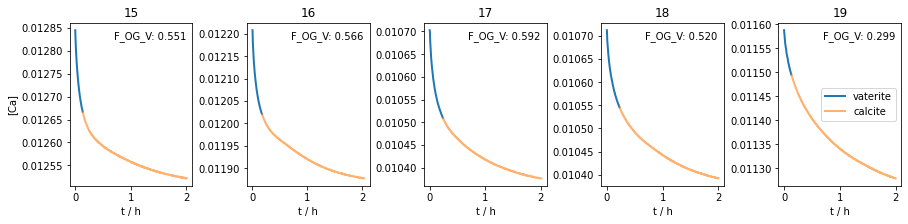

In [292]:
fig, axs = plt.subplots(1, n, sharey=False, sharex='col', figsize=[n * 2.5, 3], constrained_layout=True)

if n == 1:
    axs = [axs]
    
for ax, exp in zip(axs, exps):

    ind = profiles.loc[:, (exp, 'precip_V')]

    ax.plot(profiles.loc[ind].index, profiles.loc[ind, (exp, 'Ca')], color='C0', label='vaterite', lw=2)
    ax.plot(profiles.loc[~ind].index, profiles.loc[~ind, (exp, 'Ca')], color='C1', label='calcite', lw=2, alpha=0.6)
    ax.set_title(exp)
    f_og_v = noms(compositions.loc[int(exp), ('overgrowth', 'F_V')]).item()
    ax.text(.95, .95, f'F_OG_V: {f_og_v:.3f}', ha='right', va='top', transform=ax.transAxes)
    ax.set_xlabel('t / h')
axs[-1].legend(loc='center right')

axs[0].set_ylabel('[Ca]')

Text(0, 0.5, 'R (mol / m2 / s)')

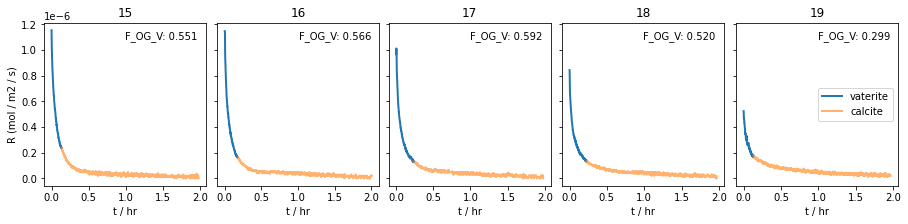

In [294]:
fig, axs = plt.subplots(1, n, sharey='row', sharex='col', figsize=[n * 2.5, 3], constrained_layout=True)

if n == 1:
    axs = [axs]
    
for ax, exp in zip(axs, exps):

    ind = profiles.loc[:, (exp, 'precip_V')]

    ax.plot(profiles.loc[ind].index, profiles.loc[ind, (exp, 'R')], color='C0', label='vaterite', lw=2)
    ax.plot(profiles.loc[~ind].index, profiles.loc[~ind, (exp, 'R')], color='C1', label='calcite', lw=2, alpha=0.6)
    ax.set_title(exp)
    f_og_v = noms(compositions.loc[int(exp), ('overgrowth', 'F_V')]).item()
    ax.text(.95, .95, f'F_OG_V: {f_og_v:.3f}', ha='right', va='top', transform=ax.transAxes)
    ax.set_xlabel('t / hr')
axs[-1].legend(loc='center right')

axs[0].set_ylabel('R (mol / m2 / s)')

In [295]:
from sklearn.metrics import r2_score

In [391]:
def bestfit_line(x, y):
    isnan = (np.isnan(x) | np.isnan(y)).values
    isreal = np.isfinite(x) & np.isfinite(y)
    
    if sum(~isnan) < 3:
        return None, None
    
    x = x[~isnan & isreal].values
    y = y[~isnan & isreal].values
    
    p = np.polyfit(x, y, 1)
    pred = np.polyval(p, x)
    r2 = r2_score(y, pred)
            
    return p, r2

/usr/lib/python3.10/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/lib/python3.10/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/lib/python3.10/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/lib/python3.10/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0, 0.5, 'Polynuclear Growth\n$\\ln{(R / F(S))}$')

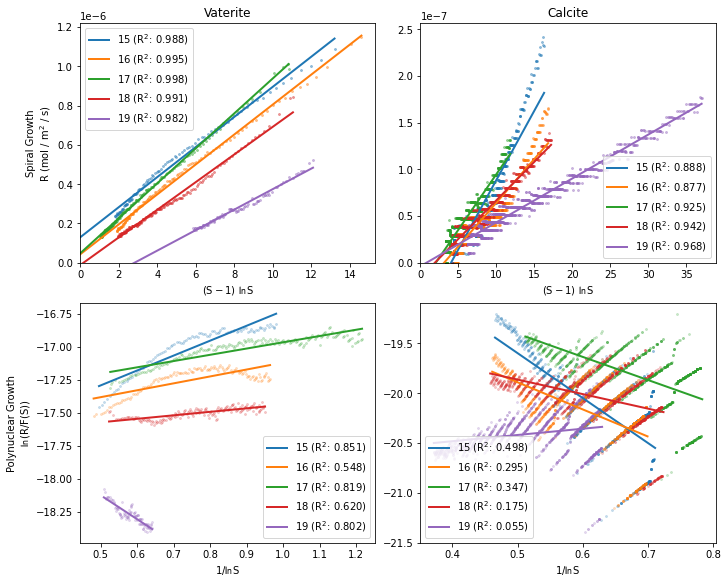

In [403]:
fig, axs = plt.subplots(2, 2, figsize=[10, 8], constrained_layout=True)

vfits_sp = {}
cfits_sp = {}

for exp in exps:
    index = profiles.loc[:, (exp, 'precip_V')]

    for i, (ind, s) in enumerate(zip([index, ~index], ['SV', 'SC'])):
        
        # spiral growth
        x = (profiles.loc[ind, (exp, s)] - 1) * np.log(profiles.loc[ind, (exp, s)])
        
        # line of best fit
        p, r2 = bestfit_line(x, profiles.loc[ind, (exp, 'R')])
        
        xn = np.linspace(0, x.max())
        lpred = np.polyval(p, xn)
        line = axs[0,i].plot(xn, lpred, label=f'{exp} ($R^2$: {r2:.3f})', lw=2)
        
        ecol = line[0].get_color()
        
        axs[0,i].scatter(x, profiles.loc[ind, (exp, 'R')], marker='.', color=ecol, zorder=-2, s=15, alpha=0.4)

        
        # polynuclear growth
        x = 1 / np.log(profiles.loc[ind, (exp, s)])
        S = profiles.loc[ind, (exp, s)]
        F = S**(7/6) * (S - 1)**(2/3) * np.log(S)**(1/6)
        y = np.log(profiles.loc[ind, (exp, 'R')] / F)
        
        axs[1,i].scatter(x[ind], y[ind], marker='.', color=ecol, s=15, alpha=0.2)
        
        
        # line of best fit
        p, r2 = bestfit_line(x, y)
        
        xn = np.linspace(x.min(), x.max())
        lpred = np.polyval(p, xn)
        line = axs[1,i].plot(xn, lpred, label=f'{exp} ($R^2$: {r2:.3f})', lw=2)
        
for ax in axs[0,:]:
    ax.legend()
    ax.set_xlim(0, ax.get_xlim()[1])
    ax.set_ylim(0, ax.get_ylim()[1])
    ax.set_xlabel('$(S - 1)~\ln{S}$')

axs[0,0].set_title('Vaterite')
axs[0,1].set_title('Calcite')
axs[0,0].set_ylabel('Spiral Growth\nR (mol / $m^2$ / s)')

for ax in axs[1,:]:
    ax.legend()
    ax.set_xlabel('$1 / \ln{S}$')

axs[1,0].set_ylabel('Polynuclear Growth\n$\ln{(R / F(S))}$')